1. dividing the data to bins/sliding windows 
2. calculating the linear model
    a) add weighting per window to match sample to population - using balance package, and post-stratification weighting (to match the known distribution based on the israeli Central Bureau of Statistic )
3. creating coef_df (for each linear model summary - coefficients etc.) - run if not using the coef_df created in step9

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from balance import Sample

# --- CONFIGURATION ---
min_age = 20
max_age = 100

# Windowing strategy options: 'fixed', 'manual', 'sliding_n_subjects', 'sliding_n_years'
STRATEGY = 'manual'

# Parameters for 'fixed' — evenly spaced bins of bin_size years
bin_size = 5

# Parameters for 'manual' — specify bin edges explicitly (irregular spacing allowed)
manual_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100]

# Parameters for 'sliding_n_subjects'
window_subjects = 100
step_subjects = 50

# Parameters for 'sliding_n_years'
window_years = 5
step_years = 1

# Weighting strategy applied inside each age window:
#   'uniform' — poststratify so every birth_year gets equal total weight
#   'none'    — no weighting (equivalent to step9 unweighted OLS)
WEIGHTING_STRATEGY = 'uniform'

# Set to None to run all ROIs
ROI_FILTER = None

INFO (2026-04-26 20:18:42,949) [__init__/<module> (line 75)]: Using balance version 0.19.0
INFO (2026-04-26 20:18:42,950) [__init__/<module> (line 80)]: 
balance (Version 0.19.0) loaded:
    📖 Documentation: https://import-balance.org/
    🛠️ Help / Issues: https://github.com/facebookresearch/balance/issues/
    📄 Citation:
        Sarig, T., Galili, T., & Eilat, R. (2023).
        balance - a Python package for balancing biased data samples.
        https://arxiv.org/abs/2307.06024

    Tip: You can view this message anytime with balance.help()



# Data Prep

In [2]:
# --- 1. DATA LOADING & PREP ---
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')
# keep best scans
volumes = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')].copy()
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')
# filter by age
volumes = volumes[(volumes['age_in_years'] >= min_age) & (volumes['age_in_years'] < max_age)]
# drop rows with missing critical data
volumes = volumes.dropna(subset=['age_in_years', 'birth_year', 'sex', 'tiv'])
volumes['id'] = volumes['subject_id'].astype(str) + '_' + volumes['session_id'].astype(str)


# Windowing

In [3]:
# --- 2. WINDOW DEFINITION ---
mappings = []

# Prepare sorted metadata for sliding strategies
meta = (
    volumes[['session_id', 'age_in_years']]
    .drop_duplicates('session_id')
    .sort_values('age_in_years')
    .reset_index(drop=True)
)

if STRATEGY == 'fixed':
    bins = np.arange(min_age, max_age + bin_size, bin_size)
    volumes['age_bin'] = pd.cut(volumes['age_in_years'], bins=bins)
    volumes = volumes.dropna(subset=['age_bin'])

elif STRATEGY == 'manual':
    # Use the manually specified bin edges — allows irregular spacing
    volumes['age_bin'] = pd.cut(volumes['age_in_years'], bins=manual_bins)
    volumes = volumes.dropna(subset=['age_bin'])

elif STRATEGY == 'sliding_n_subjects':
    session_ids = meta['session_id'].values
    for i in range(0, len(session_ids) - window_subjects + 1, step_subjects):
        subset_ids = session_ids[i : i + window_subjects]
        age_min, age_max = meta.iloc[i]['age_in_years'], meta.iloc[i + window_subjects - 1]['age_in_years']
        label = f"({age_min:.1f}-{age_max:.1f})"
        for sid in subset_ids:
            mappings.append({'session_id': sid, 'age_bin': label})

elif STRATEGY == 'sliding_n_years':
    current_start = meta['age_in_years'].min()
    age_max_data = meta['age_in_years'].max()

    while (current_start + window_years) <= age_max_data:
        current_end = current_start + window_years
        mask = (meta['age_in_years'] >= current_start) & (meta['age_in_years'] < current_end)
        subset_ids = meta.loc[mask, 'session_id'].values

        if len(subset_ids) > 0:
            label = f"({current_start:.1f}-{current_end:.1f})"
            for sid in subset_ids:
                mappings.append({'session_id': sid, 'age_bin': label})

        current_start += step_years

# Merge back for all sliding strategies
if 'sliding' in STRATEGY:
    map_df = pd.DataFrame(mappings)
    volumes = volumes.merge(map_df, on='session_id')

# Analysis and weighting

In [4]:
def plot_weighting_diagnostic(df_subjects, bin_label):
    """
    Show birth_year distribution before and after weighting for one age window.
    df_subjects must have columns: birth_year, ps_weight.
    """
    weights = df_subjects['ps_weight'].values
    n_raw = len(df_subjects)
    ess = (weights.sum() ** 2) / (weights ** 2).sum()
    ess_pct = (ess / n_raw) * 100
    n_years = df_subjects['birth_year'].nunique()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

    # Raw distribution
    sns.histplot(data=df_subjects, x='birth_year', bins=n_years,
                 ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f"Raw  (N={n_raw})")
    axes[0].set_xlabel("Birth Year")
    axes[0].set_ylabel("Subject Count")

    # Weighted distribution
    sns.histplot(data=df_subjects, x='birth_year', bins=n_years,
                 weights=weights, ax=axes[1], color='salmon', edgecolor='black')
    axes[1].axhline(y=n_raw / n_years, color='red', linestyle='--',
                    alpha=0.6, label='Perfectly Uniform')
    axes[1].set_title(f"Weighted  (ESS={ess:.1f}, {ess_pct:.1f}% of N)")
    axes[1].set_xlabel("Birth Year")
    axes[1].set_ylabel("Weighted Count")
    axes[1].legend()

    plt.suptitle(f"Birth-Year Distribution — Age Window {bin_label}", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def compute_uniform_weights(df_subjects):
    """
    Use balance (poststratify) to give equal total weight to every birth year
    observed in this window.

    Each unique birth year is treated as a stratum (categorical). The target
    has exactly one synthetic subject per stratum, so post-stratification
    produces weights proportional to 1/count_per_year — i.e. underrepresented
    years are upweighted and overrepresented years are downweighted.

    Weights are normalised so sum(weights) == N (preserves regression df).

    Returns a pd.Series aligned to df_subjects' index.
    """
    sample_df = df_subjects[['id', 'birth_year']].copy()
    # Treat birth_year as categorical string so balance uses discrete strata
    sample_df['birth_year'] = sample_df['birth_year'].astype(int).astype(str)

    unique_years = sample_df['birth_year'].unique()
    target_df = pd.DataFrame({
        'id': [f"t_{y}" for y in unique_years],
        'birth_year': unique_years,   # one row per year → uniform target
    })

    s = Sample.from_frame(sample_df, id_column='id')
    target_s = Sample.from_frame(target_df, id_column='id')

    adjusted = s.adjust(target_s, method="poststratify")

    # weight_column is a pd.Series indexed to the sample rows
    raw_weights = adjusted.weight_column.values.astype(float)

    # Normalise: sum(w) = N
    raw_weights = raw_weights / raw_weights.sum() * len(raw_weights)
    return pd.Series(raw_weights, index=df_subjects.index)

Processing Age Windows:   0%|          | 0/10 [00:00<?, ?it/s]WARNING (2026-04-26 20:22:00,263) [sample_frame/from_frame (line 321)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-04-26 20:22:00,269) [sample_frame/from_frame (line 321)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-04-26 20:22:00,271) [balance_frame/adjust (line 834)]: High-cardinality features detected that may not provide signal: birth_year (unique=26; unique_ratio=1.00)
INFO (2026-04-26 20:22:00,273) [adjustment/apply_transformations (line 433)]: Adding the variables: []
INFO (2026-04-26 20:22:00,274) [adjustment/apply_transformations (line 434)]: Transforming the variables: ['birth_year']
INFO (2026-04-26 20:22:00,275) [adjustment/apply_transformations (line 469)]: Final variables in output: ['birth_year']


[(20, 25]] balance weighting failed: 'str' object has no attribute 'values'. Falling back to inverse-count.


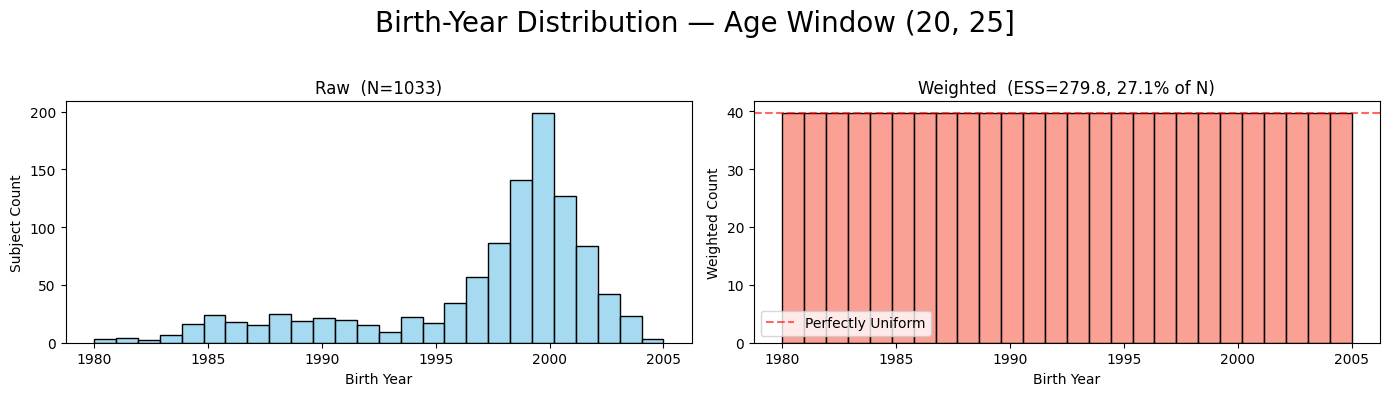

Processing Age Windows:  10%|█         | 1/10 [00:09<01:27,  9.68s/it]WARNING (2026-04-26 20:22:08,317) [sample_frame/from_frame (line 321)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-04-26 20:22:08,323) [sample_frame/from_frame (line 321)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-04-26 20:22:08,325) [balance_frame/adjust (line 834)]: High-cardinality features detected that may not provide signal: birth_year (unique=26; unique_ratio=1.00)
INFO (2026-04-26 20:22:08,327) [adjustment/apply_transformations (line 433)]: Adding the variables: []
INFO (2026-04-26 20:22:08,327) [adjustment/apply_transformations (line 434)]: Transforming the variables: ['birth_year']
INFO (2026-04-26 20:22:08,329) [adjustment/apply_transformations (line 469)]: Final variables in output: ['birth_year']


[(25, 30]] balance weighting failed: 'str' object has no attribute 'values'. Falling back to inverse-count.


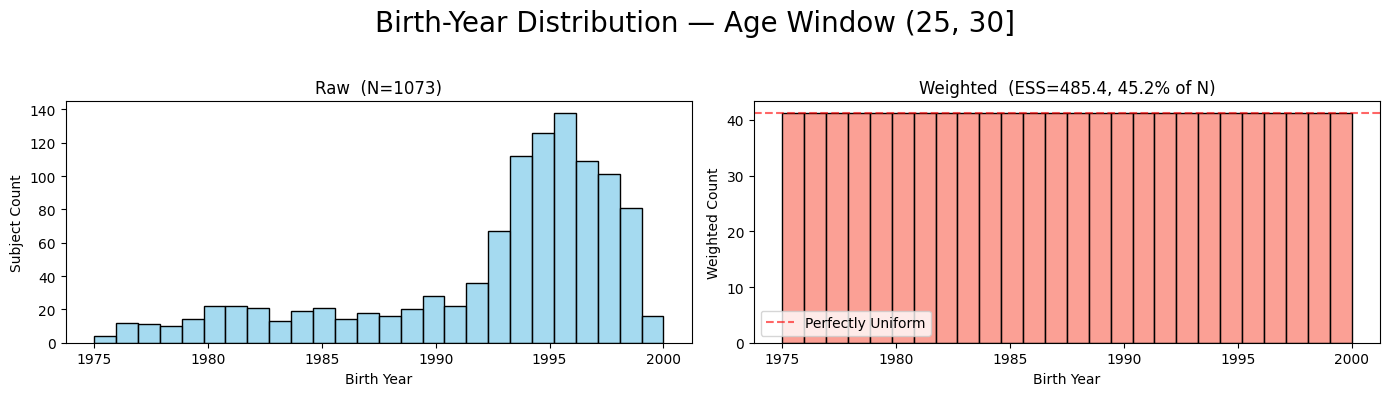

Processing Age Windows:  20%|██        | 2/10 [00:17<01:09,  8.66s/it]WARNING (2026-04-26 20:22:16,269) [sample_frame/from_frame (line 321)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-04-26 20:22:16,275) [sample_frame/from_frame (line 321)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-04-26 20:22:16,277) [balance_frame/adjust (line 834)]: High-cardinality features detected that may not provide signal: birth_year (unique=25; unique_ratio=1.00)
INFO (2026-04-26 20:22:16,279) [adjustment/apply_transformations (line 433)]: Adding the variables: []
INFO (2026-04-26 20:22:16,280) [adjustment/apply_transformations (line 434)]: Transforming the variables: ['birth_year']
INFO (2026-04-26 20:22:16,281) [adjustment/apply_transformations (line 469)]: Final variables in output: ['birth_year']


[(30, 35]] balance weighting failed: 'str' object has no attribute 'values'. Falling back to inverse-count.


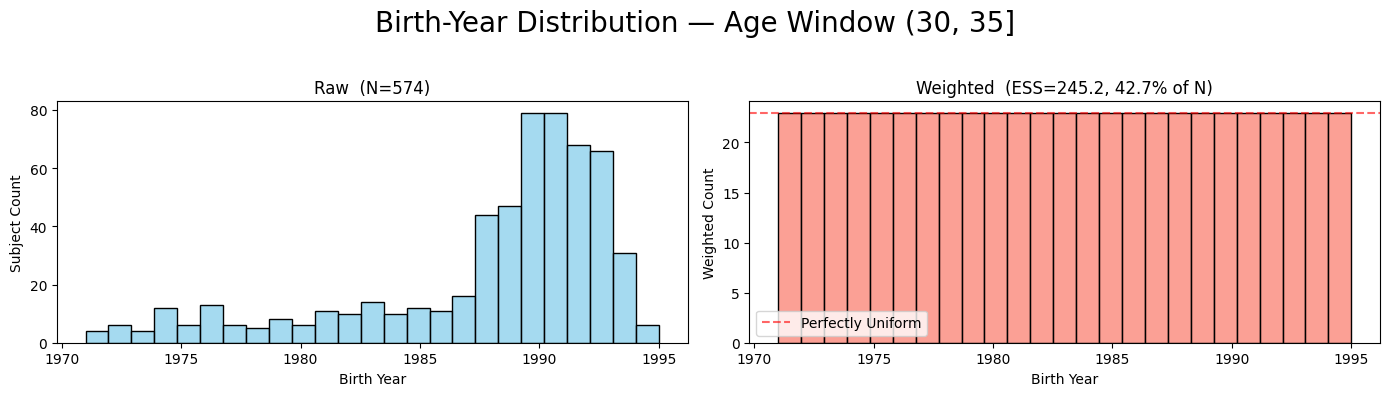

Processing Age Windows:  30%|███       | 3/10 [00:24<00:56,  8.01s/it]WARNING (2026-04-26 20:22:23,505) [sample_frame/from_frame (line 321)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-04-26 20:22:23,511) [sample_frame/from_frame (line 321)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-04-26 20:22:23,513) [balance_frame/adjust (line 834)]: High-cardinality features detected that may not provide signal: birth_year (unique=23; unique_ratio=1.00)
INFO (2026-04-26 20:22:23,515) [adjustment/apply_transformations (line 433)]: Adding the variables: []
INFO (2026-04-26 20:22:23,516) [adjustment/apply_transformations (line 434)]: Transforming the variables: ['birth_year']
INFO (2026-04-26 20:22:23,517) [adjustment/apply_transformations (line 469)]: Final variables in output: ['birth_year']


[(35, 40]] balance weighting failed: 'str' object has no attribute 'values'. Falling back to inverse-count.


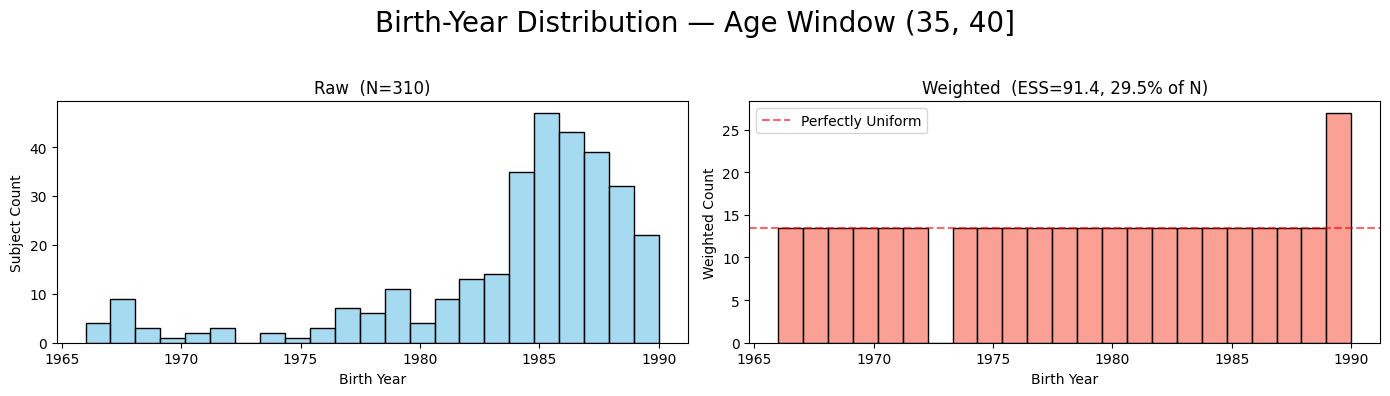

Processing Age Windows:  30%|███       | 3/10 [00:26<01:02,  8.97s/it]


KeyboardInterrupt: 

In [6]:
# --- 3. ANALYSIS ---
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")
results = []

# --- Initialize containers for weights and diagnostics ---
all_weights_records = []
window_diagnostics = []
weight_records = []


volumes_to_analyze = volumes[volumes['region_label'].isin(ROI_FILTER)] if ROI_FILTER is not None else volumes

for bin_label, df_bin in tqdm(volumes_to_analyze.groupby('age_bin', observed=True), desc="Processing Age Windows"):

    # One deduplicated row per subject for this window
    df_window = df_bin.drop_duplicates(subset=['subject_id'], keep='first').copy()

    if len(df_window) < 20:
        continue

    # --- WEIGHTING ---
    if WEIGHTING_STRATEGY == 'uniform':
        try:
            df_window['ps_weight'] = compute_uniform_weights(df_window)
        except Exception as e:
            print(f"[{bin_label}] balance weighting failed: {e}. Falling back to inverse-count.")
            counts = df_window['birth_year'].value_counts()
            df_window['ps_weight'] = df_window['birth_year'].map(1.0 / counts)
            df_window['ps_weight'] *= len(df_window) / df_window['ps_weight'].sum()
    else:  # 'none'
        df_window['ps_weight'] = 1.0

    # Collect: keep bin_label as the actual Interval object (not str)
    weight_records.append(
        df_window[['subject_id', 'session_id', 'ps_weight']].assign(age_bin=bin_label)
    )
    
    # --- NEW: Calculate and Store Window Diagnostics ---
    w = df_window['ps_weight'].values.astype(float)
    n_window = len(df_window)
    ess = (w.sum() ** 2) / (w ** 2).sum()
    ess_pct = ess / n_window

    window_diagnostics.append({
        'age_bin': str(bin_label),
        'n_subjects': n_window,
        'ess': ess,
        'ess_ratio': ess_pct
    })


    # Diagnostic: birth_year distribution before vs after weighting
    plot_weighting_diagnostic(df_window, bin_label)

    # --- REGRESSION PER ROI ---
    weight_lookup = df_window.set_index('subject_id')['ps_weight']
    valid_sessions = set(df_window['session_id'])

    for roi, df_roi in df_bin.groupby('region_label', observed=True):
        df_roi_f = df_roi[df_roi['session_id'].isin(valid_sessions)].copy()
        df_roi_f['ps_weight'] = df_roi_f['subject_id'].map(weight_lookup).astype(float)

        if len(df_roi_f) < 20:
            continue

        # Drop sex covariate if only one sex present in this window/ROI
        formula = ('volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years'
                   if df_roi_f['sex'].nunique() >= 2
                   else 'volume_mm3 ~ birth_year + tiv + age_in_years')

        try:
            m_raw = smf.ols(formula, data=df_roi_f).fit()
            m_wls = smf.wls(formula, data=df_roi_f, weights=df_roi_f['ps_weight'].values).fit()

            for model, label in [(m_raw, 'unweighted'), (m_wls, 'weighted')]:
                for var in model.params.index:
                    results.append({
                        'age_bin':      str(bin_label),
                        'region_label': roi,
                        'variable':     var,
                        'weighting':    label,
                        'coef':         model.params[var],
                        't':            model.tvalues[var],
                        'p':            model.pvalues[var],
                        'n_subjects':   len(df_roi_f),
                        'ess':          ess if label == 'weighted' else len(df_roi_f),
                    })
        except Exception as e:
            print(f"Regression failed — ROI {roi}, window {bin_label}: {e}")
            continue


In [ ]:
# --- 4. DATA COMPILATION & SAVING ---

# 1. Regression Results
coef_df = pd.DataFrame(results)

# 2. Subject-Level Weights (Long format: one row per subject per window)
weights_df = pd.concat(weight_records, ignore_index=True)

# add weights_df[ps_weight] to volumes by subject_id and session_id
volumes = volumes.merge(weights_df, on=['subject_id', 'session_id', 'age_bin'], how='left')


# 3. Window-Level Summary
diagnostics_df = pd.DataFrame(window_diagnostics)

In [ ]:
# TODO there's a misalignment between combined and volumes I couldn't understand why. Later steps used volumes so it's possible we lost several subject.session_ids 
print(f"len of combined df: {len(combined_df)}")
print(f" len of volumes: {len(volumes)}")

print(f"difference: {(len(combined_df) - len(volumes))/454}")

print(f"too young : {(len(combined_df[(combined_df['age_in_years'] < 20)]))/454}")
print(f"too old : {(len(combined_df[(combined_df['age_in_years'] > 100)]))/454}")

len of combined df: 2236858
 len of volumes: 2166034
difference: 156.0
too young : 144.0
too old : 1.0


# post process

In [ ]:
# --- 4. POST-PROCESSING ---
coef_df = pd.DataFrame(results)

# Add Atlas names
coef_df = coef_df.merge(atlas_csv[['index', 'name']], left_on='region_label', right_on='index', how='left')
coef_df.rename(columns={'name': 'region_name'}, inplace=True)

# Multiple Comparison Correction (FDR) per window for 'birth_year'
final_rows = []
for label, group in coef_df.groupby('age_bin'):
    mask = group['variable'] == 'birth_year'
    if mask.any():
        _, fdr_p, _, _ = multipletests(group.loc[mask, 'p'], method='fdr_bh')
        group.loc[mask, 'fdr_p'] = fdr_p
    final_rows.append(group)

coef_df = pd.concat(final_rows)

print("Analysis Complete.")

Analysis Complete.


# save

In [ ]:
# --- 5. SAVE ---

# # Save to disk
# volumes.to_pickle("/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/combined_df_with_weights_per_window.pkl")
# diagnostics_df.to_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/window_ess_summary.csv", index=False)

# coef_df
if STRATEGY == 'sliding_n_subjects':
    window_suffix = f"sliding_ws{window_subjects}_ss{step_subjects}"
elif STRATEGY == 'sliding_n_years':
    window_suffix = f"sliding_wy{window_years}_sy{step_years}"
elif STRATEGY == 'manual':
    window_suffix = "manual_bins"
else:
    window_suffix = f"fixed_bin{bin_size}"

suffix = f"{window_suffix}_w{WEIGHTING_STRATEGY}"

# out_path = f"/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_{suffix}.csv"
# coef_df.to_csv(out_path, index=False)
# print(f"Saved → {out_path}")